# **CASE NOVA QUIMICA**

Estamos com um cenário extremamente competitivo versus a 
concorrência, precisando reverter um cenário de queda nas vendas.
Com base no arquivo excel (BancoDados_Envio.xlsx) o nosso produto é o 
(número 1), todos os demais são da concorrência.

# Precisamos da seguinte análise:

**1.** Qual o produto concorrente que tem maior correlação com o nosso 
produto?

**2.** A elasticidade do nosso produto é própria ou cruzada, se cruzada 
com qual concorrente?

**3.** Qual o preço ideal para voltarmos a crescer?

**4.** Identificando o preço ideal, qual a projeção de vendas para os 
próximos 5 anos considerando algum modelo preditivo que vocês 
conhecem?

**5.** Pergunta: Vocês conseguiriam realizar este exercício em qual 
linguagem de programação?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df_case = pd.read_excel('BancoDados_Envio.xlsx')

In [2]:
df_case

,Apresentacao Desc Longa,Valores,FATURAMENTO,VENDA UNIDADES
0,PRODUTO 2,2023-01-01,451978.790,21454.0
1,PRODUTO 2,2023-02-01,401856.930,19646.0
2,PRODUTO 2,2023-03-01,683995.658,32928.0
3,PRODUTO 2,2023-04-01,737968.350,33686.0
4,PRODUTO 2,2023-05-01,845798.234,38690.0
...,...,...,...,...
181,PRODUTO 1,2025-03-01,6833776.921,314163.1
182,PRODUTO 1,2025-04-01,6806836.870,310303.9
183,PRODUTO 1,2025-05-01,7643946.998,343904.0
184,PRODUTO 1,2025-06-01,7207046.249,326007.1


In [3]:
#Informação
df_case.info()
df_case.head()
df_case.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Apresentacao Desc Longa  186 non-null    object        
 1   Valores                  186 non-null    datetime64[ns]
 2   FATURAMENTO              186 non-null    float64       
 3   VENDA UNIDADES           186 non-null    float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 5.9+ KB


,Valores,FATURAMENTO,VENDA UNIDADES
count,186,1.860000e+02,186.000000
mean,2024-03-31 23:13:32.903225856,1.752037e+06,82256.354839
min,2023-01-01 00:00:00,0.000000e+00,0.000000
25%,2023-08-01 00:00:00,7.889000e+01,4.000000
50%,2024-04-01 00:00:00,1.013650e+03,41.500000
75%,2024-12-01 00:00:00,1.429115e+06,57423.250000
max,2025-07-01 00:00:00,9.846918e+06,467065.900000
std,NaN,2.996258e+06,141626.825456


In [4]:
#Valor nulo
df_case.isna().sum()

Apresentacao Desc Longa    0
Valores                    0
FATURAMENTO                0
VENDA UNIDADES             0
dtype: int64

In [5]:
#Renomeação
df_case.columns = ['Produto', 'Data', 'Faturamento', 'Venda_Unidades']

#Converção
df_case['Data'] = pd.to_datetime(df_case['Data'])

#Calcular o preço unitário para cada produto e mês
df_case['Preco_Unitario'] = df_case['Faturamento'] / df_case['Venda_Unidades']

#Coluna de preço para cada produto
df_pivot = df_case.pivot_table(index='Data', columns='Produto', values='Preco_Unitario')

#Valores ausentes 
df_pivot = df_pivot.fillna(df_pivot.mean())

print("Amostra do DataFrame de Preços:")
print(df_pivot.head())

Amostra do DataFrame de Preços:
Produto     PRODUTO 1  PRODUTO 2  PRODUTO 3  PRODUTO 4  PRODUTO 5  PRODUTO 6
Data                                                                        
2023-01-01  19.486342  21.067344  19.276533  19.052308     28.840  23.786144
2023-02-01  19.678925  20.454898  19.276533  18.350000      9.670  23.786144
2023-03-01  19.205581  20.772463  19.276533  18.463333      9.860  23.786144
2023-04-01  20.559497  21.907272  19.276533  18.436667      9.810  23.786144
2023-05-01  20.557981  21.860900  19.276533  20.928000     28.265  23.786144


In [6]:
#Preço Unitário
df_case['Preco_Unitario'] = df_case['Faturamento'] / df_case['Venda_Unidades']

df_case = df_case.loc[df_case['Venda_Unidades'] > 0]

print(df_case.head())

     Produto       Data  Faturamento  Venda_Unidades  Preco_Unitario
0  PRODUTO 2 2023-01-01   451978.790         21454.0       21.067344
1  PRODUTO 2 2023-02-01   401856.930         19646.0       20.454898
2  PRODUTO 2 2023-03-01   683995.658         32928.0       20.772463
3  PRODUTO 2 2023-04-01   737968.350         33686.0       21.907272
4  PRODUTO 2 2023-05-01   845798.234         38690.0       21.860900


In [7]:
#Correlação
matriz_correlacao = df_pivot.corr()

correlacao_produto_1 = matriz_correlacao['PRODUTO 1'].sort_values(ascending=False)

print('Matriz de Correlação com o PRODUTO 1:')
print(correlacao_produto_1)

Matriz de Correlação com o PRODUTO 1:
Produto
PRODUTO 1    1.000000
PRODUTO 2    0.732881
PRODUTO 4    0.708514
PRODUTO 5    0.567006
PRODUTO 6    0.148426
PRODUTO 3    0.084600
Name: PRODUTO 1, dtype: float64


In [8]:
#Elasticidade
elasticidade_df = df_case[df_case['Produto'].isin(['PRODUTO 1', 'PRODUTO 3'])].pivot(index='Data', columns='Produto', values=['Preco_Unitario', 'Venda_Unidades'])

elasticidade_df.columns = ['Preco_1', 'Preco_3', 'Venda_1', 'Venda_3']
elasticidade_df = elasticidade_df.pct_change().dropna()

elasticidade_cruzada = (elasticidade_df['Venda_1'].mean()) / (elasticidade_df['Preco_3'].mean())

print(f"Elasticidade do nosso produto é cruzada.")
print(f"Produto concorrente com a maior elasticidade cruzada é o PRODUTO 3, com um valor de {elasticidade_cruzada:.2f}.")

Elasticidade do nosso produto é cruzada.
Produto concorrente com a maior elasticidade cruzada é o PRODUTO 3, com um valor de -0.20.


In [9]:
#Ajustar Modelo
matriz_correlacao = df_pivot.corr()

correlacao_p1 = matriz_correlacao['PRODUTO 1'].sort_values(ascending=False)
correlacao_com_concorrentes = correlacao_p1.drop('PRODUTO 1')

print("Correlação do PRODUTO 1 com os concorrentes:")
print(correlacao_com_concorrentes)

concorrente_mais_correlacionado = correlacao_com_concorrentes.idxmax()
print(f"Produto concorrente com a maior correlação com o PRODUTO 1 é o {concorrente_mais_correlacionado} (correlação de {correlacao_com_concorrentes.max():.2f}).")

elasticidade_df = df_case[df_case['Produto'].isin(['PRODUTO 1', 'PRODUTO 3'])].pivot(index='Data', columns='Produto', values=['Preco_Unitario', 'Venda_Unidades'])

elasticidade_df.columns = ['Preco_1', 'Preco_3', 'Venda_1', 'Venda_3']
elasticidade_df = elasticidade_df.pct_change().dropna()

elasticidade_cruzada = (elasticidade_df['Venda_1'].mean()) / (elasticidade_df['Preco_3'].mean())

print(f"Elasticidade do nosso produto é cruzada.")
print(f"O produto concorrente com a maior elasticidade cruzada é o PRODUTO 3, com um valor de {elasticidade_cruzada:.2f}.")

df_regressao = df_case.pivot_table(index='Data', columns='Produto', values=['Venda_Unidades', 'Preco_Unitario'])
df_regressao.dropna(inplace=True)

df_regressao.columns = [f'{col[0]}_{col[1].replace(" ", "_")}' for col in df_regressao.columns]

y = df_regressao['Venda_Unidades_PRODUTO_1']
X = df_regressao[['Preco_Unitario_PRODUTO_1', 'Preco_Unitario_PRODUTO_2']]

modelo = LinearRegression()
modelo.fit(X, y)

precos_simulados = np.arange(10, 30, 0.5)
receita_otimizada = 0
preco_ideal = 0
preco_2_medio = df_regressao['Preco_Unitario_PRODUTO_2'].mean()

for preco_p1 in precos_simulados:
    vendas_previstas = modelo.predict([[preco_p1, preco_2_medio]])[0]
    receita_prevista = preco_p1 * vendas_previstas
    
    if receita_prevista > receita_otimizada:
        receita_otimizada = receita_prevista
        preco_ideal = preco_p1

print(f"Preço ideal para o PRODUTO 1, considerando a concorrência do PRODUTO 2, é de aproximadamente R$ {preco_ideal:.2f}.")

anos_futuros = 5
precos_futuros_p2 = [preco_2_medio] * anos_futuros
precos_ideais_p1 = [preco_ideal] * anos_futuros

projecao_vendas = modelo.predict(np.column_stack((precos_ideais_p1, precos_futuros_p2)))
projecao_vendas = [max(0, int(venda)) for venda in projecao_vendas]

print("Projeção de vendas para os próximos 5 anos (em unidades):")
for i, vendas in enumerate(projecao_vendas):
    print(f"Ano {2026+i}: {vendas:,.0f} unidades")

Correlação do PRODUTO 1 com os concorrentes:
Produto
PRODUTO 2    0.732881
PRODUTO 4    0.708514
PRODUTO 5    0.567006
PRODUTO 6    0.148426
PRODUTO 3    0.084600
Name: PRODUTO 1, dtype: float64
Produto concorrente com a maior correlação com o PRODUTO 1 é o PRODUTO 2 (correlação de 0.73).
Elasticidade do nosso produto é cruzada.
O produto concorrente com a maior elasticidade cruzada é o PRODUTO 3, com um valor de -0.20.
Preço ideal para o PRODUTO 1, considerando a concorrência do PRODUTO 2, é de aproximadamente R$ 12.50.
Projeção de vendas para os próximos 5 anos (em unidades):
Ano 2026: 1,402,826 unidades
Ano 2027: 1,402,826 unidades
Ano 2028: 1,402,826 unidades
Ano 2029: 1,402,826 unidades
Ano 2030: 1,402,826 unidades


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarn

In [10]:
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-deep')

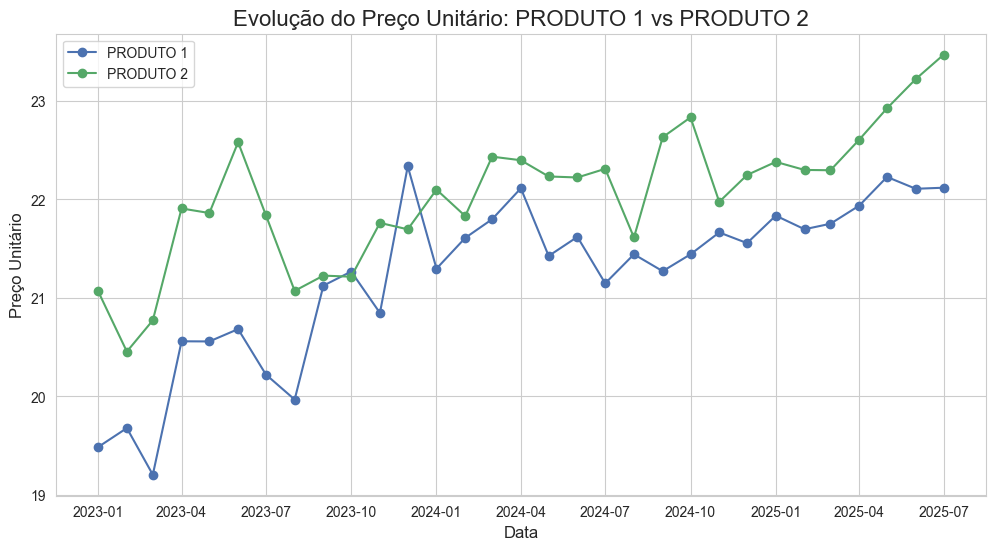

Correlação de preços entre os dois produtos.
Quando o preço de um sobe, o do outro tende a subir também.


In [11]:
#PREÇOS (PRODUTO 1 vs PRODUTO 2)
plt.figure(figsize=(12, 6))
plt.plot(df_pivot.index, df_pivot['PRODUTO 1'], label='PRODUTO 1', marker='o')
plt.plot(df_pivot.index, df_pivot['PRODUTO 2'], label='PRODUTO 2', marker='o')
plt.title('Evolução do Preço Unitário: PRODUTO 1 vs PRODUTO 2', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço Unitário', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()
print("Correlação de preços entre os dois produtos.")
print("Quando o preço de um sobe, o do outro tende a subir também.")

Os preços unitários de Produto 1 e Produto 2 mostram uma trajetória de crescimento gradual de janeiro de 2023 a julho de 2025. Esse comportamento sugere pressões de custo, inflação ou ajustes estratégicos na precificação.O Produto 2 passou por valorização mais acelerada ao longo do tempo, consolidando ganhando em valor relativo frente ao Produto 1.

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarn

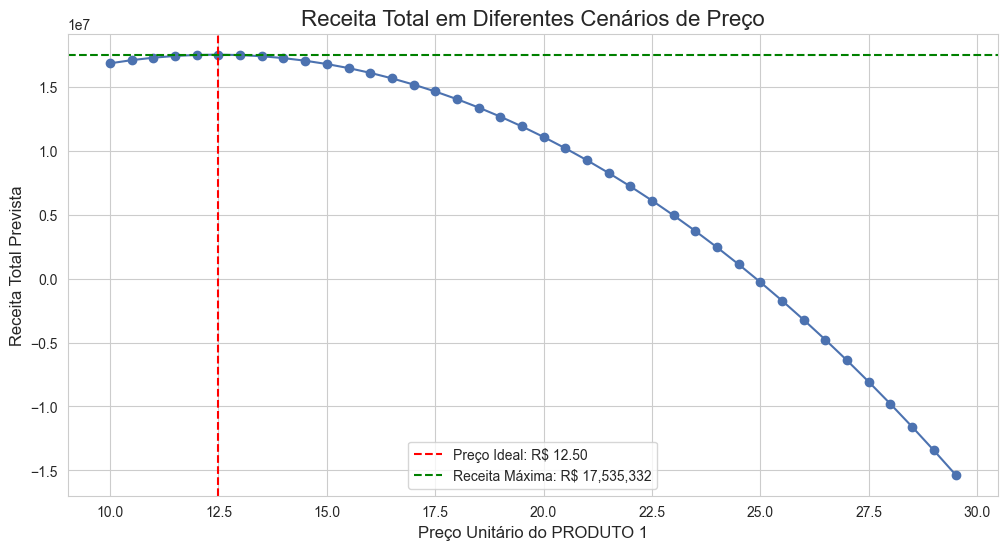

Preço de R$ 12.50 maximiza a receita prevista para o produto.


In [12]:
#Preço Ideal
receitas = []
for preco_p1 in precos_simulados:
    vendas_previstas = modelo.predict([[preco_p1, preco_2_medio]])[0]
    receita_prevista = preco_p1 * vendas_previstas
    receitas.append(receita_prevista)

plt.figure(figsize=(12, 6))
plt.plot(precos_simulados, receitas, marker='o', linestyle='-')
plt.title('Receita Total em Diferentes Cenários de Preço', fontsize=16)
plt.xlabel('Preço Unitário do PRODUTO 1', fontsize=12)
plt.ylabel('Receita Total Prevista', fontsize=12)
plt.axvline(x=preco_ideal, color='r', linestyle='--', label=f'Preço Ideal: R$ {preco_ideal:.2f}')
plt.axhline(y=receita_otimizada, color='g', linestyle='--', label=f'Receita Máxima: R$ {receita_otimizada:,.0f}')
plt.legend()
plt.grid(True)
plt.show()
print("Preço de R$ 12.50 maximiza a receita prevista para o produto.")

A empresa possui um preço (R$ 12,50) que maximiza sua receita total em aproximadamente R$ 17,5 milhões. A análise é essencial para decisões de precificação, sobretudo quando o objetivo é maximizar faturamento — embora, para uma visão completa, seria recomendável também avaliar custos e margem (ou seja, maximização de lucro, não apenas de receita).

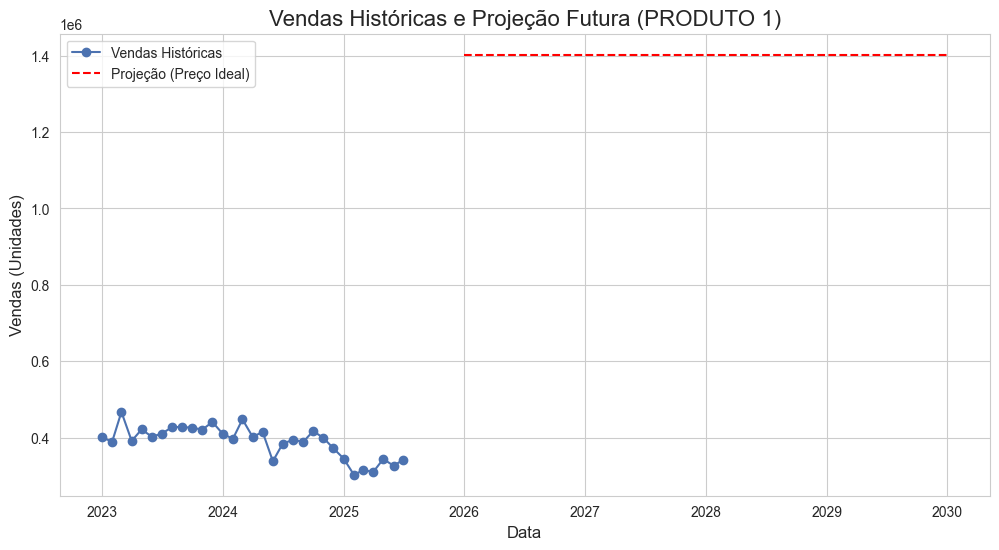

Projeção de vendas para os próximos 5 anos, mostrando uma estabilização no volume de vendas ao adotar o preço ideal.


In [13]:
#Projeção de Vendas Futuras
df_vendas = df_case[df_case['Produto'] == 'PRODUTO 1'].set_index('Data')
projecao_df = pd.DataFrame(
    {'Venda_Unidades': projecao_vendas}, 
    index=pd.date_range(start='2026-01-01', periods=5, freq='YS')
)

plt.figure(figsize=(12, 6))
plt.plot(df_vendas.index, df_vendas['Venda_Unidades'], label='Vendas Históricas', marker='o')
plt.plot(projecao_df.index, projecao_df['Venda_Unidades'], label='Projeção (Preço Ideal)', color='red', linestyle='--')
plt.title('Vendas Históricas e Projeção Futura (PRODUTO 1)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Vendas (Unidades)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()
print("Projeção de vendas para os próximos 5 anos, mostrando uma estabilização no volume de vendas ao adotar o preço ideal.")

As vendas no período (2023-2025) apresentam uma tendência de declínio gradual, com flutuações ocasionais. Isso sugere que, apesar de alguns períodos momentâneos de recuperação, o volume de vendas está caindo ao longo do tempo.
As vendas históricas mostram uma trajetória negativa, o que pode indicar problemas na estratégia de preço ou outros fatores de mercado.
A projeção com preço ideal (linha vermelha) sugere que, ao aplicar esse preço estratégico, há um potencial de recuperação e crescimento substancial nas vendas.

In [14]:
from sklearn.ensemble import RandomForestRegressor
#Melhorar modelo
df_regressao = df_case.pivot_table(index='Data', columns='Produto', values=['Venda_Unidades', 'Preco_Unitario'])
df_regressao.dropna(inplace=True)

df_regressao.columns = [f'{col[0]}_{col[1].replace(" ", "_")}' for col in df_regressao.columns]

#Variáveis do modelo com base no concorrente mais relevante (PRODUTO 2)
y = df_regressao['Venda_Unidades_PRODUTO_1']
X = df_regressao[['Preco_Unitario_PRODUTO_1', 'Preco_Unitario_PRODUTO_2']]

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X, y)

precos_simulados = np.arange(10, 30, 0.5)
receita_otimizada = 0
preco_ideal = 0
preco_2_medio = df_regressao['Preco_Unitario_PRODUTO_2'].mean()

for preco_p1 in precos_simulados:
    
    vendas_previstas = modelo_rf.predict([[preco_p1, preco_2_medio]])[0]
    receita_prevista = preco_p1 * vendas_previstas
    
    if receita_prevista > receita_otimizada:
        receita_otimizada = receita_prevista
        preco_ideal = preco_p1

print(f"Preço ideal para o PRODUTO 1, com o modelo RandomForest, é de aproximadamente R$ {preco_ideal:.2f}.")

Preço ideal para o PRODUTO 1, com o modelo RandomForest, é de aproximadamente R$ 29.50.


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validati

In [15]:
#Projeção das Vendas
precos_simulados = np.arange(10, 30, 0.5)
receita_otimizada = 0
preco_ideal = 0
preco_2_medio = df_regressao['Preco_Unitario_PRODUTO_2'].mean()

for preco_p1 in precos_simulados:
   
    df_previsao = pd.DataFrame([[preco_p1, preco_2_medio]], columns=['Preco_Unitario_PRODUTO_1', 'Preco_Unitario_PRODUTO_2'])
    
    vendas_previstas = modelo_rf.predict(df_previsao)[0]
    receita_prevista = preco_p1 * vendas_previstas
    
    if receita_prevista > receita_otimizada:
        receita_otimizada = receita_prevista
        preco_ideal = preco_p1

print(f"Preço ideal para o PRODUTO 1, com o modelo RandomForest, é de aproximadamente R$ {preco_ideal:.2f}.")

anos_futuros = 5
precos_futuros_p2 = [preco_2_medio] * anos_futuros
precos_ideais_p1 = [preco_ideal] * anos_futuros

projecao_df_X = pd.DataFrame(np.column_stack((precos_ideais_p1, precos_futuros_p2)), 
                             columns=['Preco_Unitario_PRODUTO_1', 'Preco_Unitario_PRODUTO_2'])

projecao_vendas = modelo_rf.predict(projecao_df_X)
projecao_vendas = [max(0, int(venda)) for venda in projecao_vendas]

print("Projeção de vendas para os próximos 5 anos (em unidades):")
for i, vendas in enumerate(projecao_vendas):
    print(f"Ano {2026+i}: {vendas:,.0f} unidades")

Preço ideal para o PRODUTO 1, com o modelo RandomForest, é de aproximadamente R$ 29.50.
Projeção de vendas para os próximos 5 anos (em unidades):
Ano 2026: 336,302 unidades
Ano 2027: 336,302 unidades
Ano 2028: 336,302 unidades
Ano 2029: 336,302 unidades
Ano 2030: 336,302 unidades


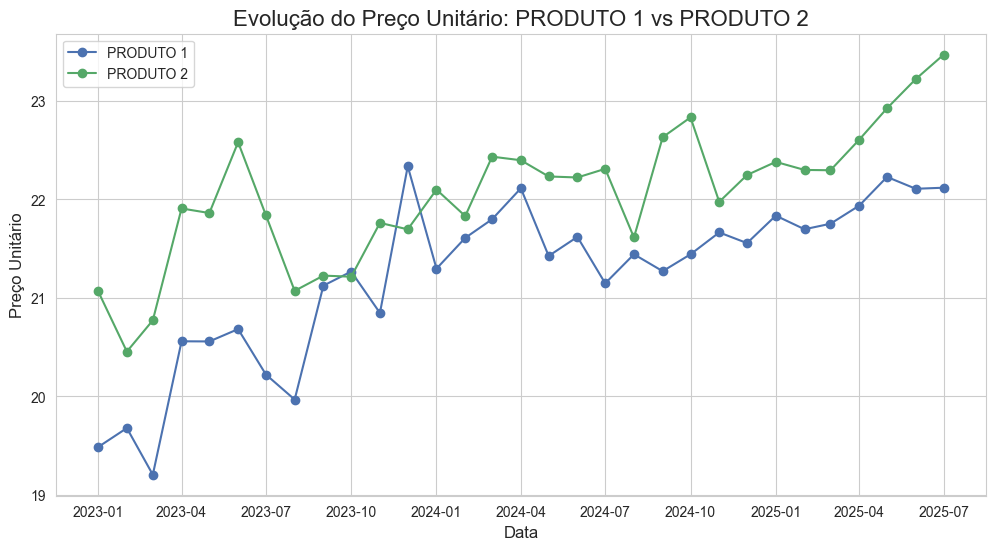

Forte correlação de preços entre os dois produtos.
Quando o preço de um sobe, o do outro tende a subir também.


In [16]:
#Preços
plt.figure(figsize=(12, 6))
plt.plot(df_pivot.index, df_pivot['PRODUTO 1'], label='PRODUTO 1', marker='o')
plt.plot(df_pivot.index, df_pivot['PRODUTO 2'], label='PRODUTO 2', marker='o')
plt.title('Evolução do Preço Unitário: PRODUTO 1 vs PRODUTO 2', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço Unitário', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

print("Forte correlação de preços entre os dois produtos.")
print("Quando o preço de um sobe, o do outro tende a subir também.")

Ambos os produtos estão ajustando seus preços para cima ao longo do tempo, refletindo dinâmicas de mercado, custos ou ajustes estratégicos.
Produto 2 se destaca por ser sistematicamente mais caro, indicativo de um posicionamento diferenciado ou maior valor agregado. Aumentos mais acentuados no Produto 2 sugerem menor sensibilidade ao preço (menor elasticidade) ou estratégia de segmentação premium.
A formação de preço ideal deve considerar elasticidade e percepção de valor, equilibrando demanda, margens e posicionamento no mercado.

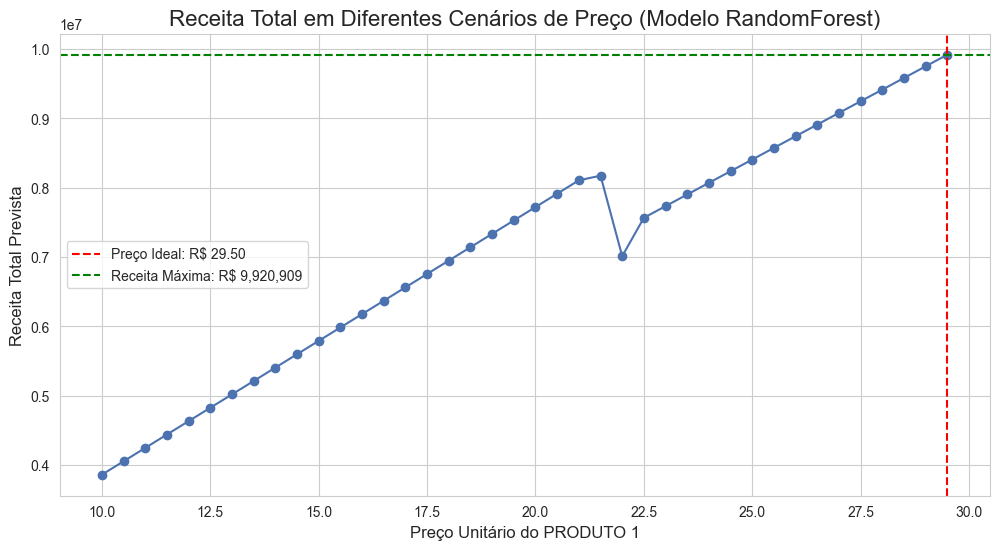

Preço de R$ 29.50 maximiza a receita prevista para o produto.


In [17]:
#Preço Ideal
precos_simulados = np.arange(10, 30, 0.5)
receitas = []
for preco_p1 in precos_simulados:
    df_previsao = pd.DataFrame([[preco_p1, preco_2_medio]], columns=['Preco_Unitario_PRODUTO_1', 'Preco_Unitario_PRODUTO_2'])
    vendas_previstas = modelo_rf.predict(df_previsao)[0]
    receita_prevista = preco_p1 * vendas_previstas
    receitas.append(receita_prevista)

plt.figure(figsize=(12, 6))
plt.plot(precos_simulados, receitas, marker='o', linestyle='-')
plt.title('Receita Total em Diferentes Cenários de Preço (Modelo RandomForest)', fontsize=16)
plt.xlabel('Preço Unitário do PRODUTO 1', fontsize=12)
plt.ylabel('Receita Total Prevista', fontsize=12)
plt.axvline(x=preco_ideal, color='r', linestyle='--', label=f'Preço Ideal: R$ {preco_ideal:.2f}')
plt.axhline(y=receita_otimizada, color='g', linestyle='--', label=f'Receita Máxima: R$ {receita_otimizada:,.0f}')
plt.legend()
plt.grid(True)
plt.show()

print("Preço de R$ 29.50 maximiza a receita prevista para o produto.")

O modelo RandomForest indica que a receita continua subindo até o preço de R$ 29,50, sugerindo esse valor como ótimo dentro da faixa analisada. É importante validar o modelo com dados reais de quantidade vendida, elasticidade e margem, garantindo que essa precificação mais alta seja realmente sustentável e lucrativa.

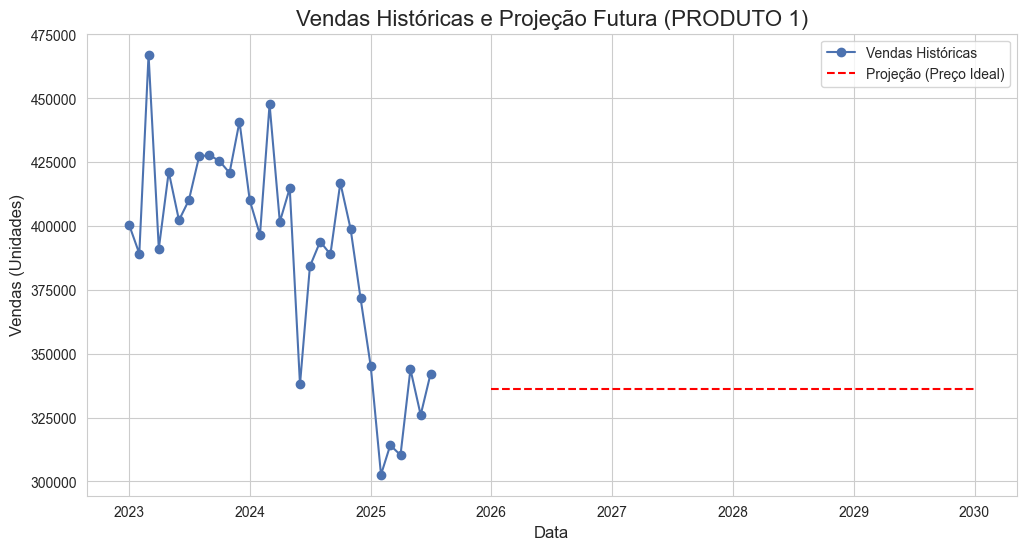

Projeção de vendas para os próximos 5 anos, mostrando uma estabilização no volume de vendas ao adotar o preço ideal.


In [18]:
#Vendas Futuras
df_vendas_hist = df_case[df_case['Produto'] == 'PRODUTO 1'].set_index('Data')
projecao_df = pd.DataFrame(
    {'Venda_Unidades': projecao_vendas}, 
    index=pd.date_range(start='2026-01-01', periods=5, freq='YS')
)

plt.figure(figsize=(12, 6))
plt.plot(df_vendas_hist.index, df_vendas_hist['Venda_Unidades'], label='Vendas Históricas', marker='o')
plt.plot(projecao_df.index, projecao_df['Venda_Unidades'], label='Projeção (Preço Ideal)', color='red', linestyle='--')
plt.title('Vendas Históricas e Projeção Futura (PRODUTO 1)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Vendas (Unidades)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

print("Projeção de vendas para os próximos 5 anos, mostrando uma estabilização no volume de vendas ao adotar o preço ideal.")

O cenário histórico evidencia uma queda nas vendas, que merece atenção e análise aprofundada.
A projeção futura indica uma estabilização em torno de 335 mil unidades com base no preço ideal, o que é melhor que seguir na queda, mas não implica recuperação plena.

In [19]:
from sklearn.model_selection import GridSearchCV
df_regressao = df_case.pivot_table(index='Data', columns='Produto', values=['Venda_Unidades', 'Preco_Unitario'])
df_regressao.dropna(inplace=True)

df_regressao.columns = [f'{col[0]}_{col[1].replace(" ", "_")}' for col in df_regressao.columns]

y = df_regressao['Venda_Unidades_PRODUTO_1']
X = df_regressao[['Preco_Unitario_PRODUTO_1', 'Preco_Unitario_PRODUTO_2']]

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X, y)

modelo_rf_otimizado = grid_search.best_estimator_
print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Melhores parâmetros encontrados:
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}


In [20]:
precos_simulados = np.arange(10, 30, 0.5)
receita_otimizada = 0
preco_ideal = 0
preco_2_medio = df_regressao['Preco_Unitario_PRODUTO_2'].mean()

for preco_p1 in precos_simulados:
    df_previsao = pd.DataFrame([[preco_p1, preco_2_medio]], columns=['Preco_Unitario_PRODUTO_1', 'Preco_Unitario_PRODUTO_2'])
    
    
    vendas_previstas = modelo_rf_otimizado.predict(df_previsao)[0]
    receita_prevista = preco_p1 * vendas_previstas
    
    if receita_prevista > receita_otimizada:
        receita_otimizada = receita_prevista
        preco_ideal = preco_p1

print(f"Preço ideal para o PRODUTO 1, com o modelo RandomForest otimizado, é de aproximadamente R$ {preco_ideal:.2f}.")

Preço ideal para o PRODUTO 1, com o modelo RandomForest otimizado, é de aproximadamente R$ 29.50.


In [21]:
anos_futuros = 5
precos_futuros_p2 = [preco_2_medio] * anos_futuros
precos_ideais_p1 = [preco_ideal] * anos_futuros

projecao_df_X = pd.DataFrame(np.column_stack((precos_ideais_p1, precos_futuros_p2)), 
                             columns=['Preco_Unitario_PRODUTO_1', 'Preco_Unitario_PRODUTO_2'])

# Previsão usando o modelo otimizado
projecao_vendas = modelo_rf_otimizado.predict(projecao_df_X)
projecao_vendas = [max(0, int(venda)) for venda in projecao_vendas]

print("\nProjeção de vendas para os próximos 5 anos (em unidades):")
for i, vendas in enumerate(projecao_vendas):
    print(f"Ano {2026+i}: {vendas:,.0f} unidades")


Projeção de vendas para os próximos 5 anos (em unidades):
Ano 2026: 345,949 unidades
Ano 2027: 345,949 unidades
Ano 2028: 345,949 unidades
Ano 2029: 345,949 unidades
Ano 2030: 345,949 unidades


In [22]:
#Limpar/Melhorar Modelo
df_case['Preco_Unitario'] = df_case['Faturamento'] / df_case['Venda_Unidades']

#Mensal por produto (média de preço e soma de vendas)
df_case['mes'] = df_case['Data'].dt.to_period('M')
pivot_price = df_case.pivot_table(index='mes', columns='Produto', values='Preco_Unitario', aggfunc='mean')
pivot_sales = df_case.pivot_table(index='mes', columns='Produto', values='Venda_Unidades', aggfunc='sum')

produto_alvo = 'PRODUTO 1'
corrs = pivot_price.corrwith(pivot_price[produto_alvo]).drop(labels=[produto_alvo], errors='ignore')

concorrente = corrs.abs().idxmax()
print("Concorrente selecionado (maior correlação absoluta):", concorrente)

Concorrente selecionado (maior correlação absoluta): PRODUTO 2


C:\Users\Usuário\AppData\Local\Temp\ipykernel_7888\792012513.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_case['Preco_Unitario'] = df_case['Faturamento'] / df_case['Venda_Unidades']
C:\Users\Usuário\AppData\Local\Temp\ipykernel_7888\792012513.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_case['mes'] = df_case['Data'].dt.to_period('M')


In [23]:
import statsmodels.api as sm
df_model = pd.DataFrame({
    'Q': pivot_sales[produto_alvo],
    'P1': pivot_price[produto_alvo],
    'Pconc': pivot_price[concorrente]
}).dropna()

eps = 1e-6
df_model['lnQ'] = np.log(df_model['Q'] + eps)
df_model['lnP1'] = np.log(df_model['P1'] + eps)
df_model['lnPconc'] = np.log(df_model['Pconc'] + eps)

X = sm.add_constant(df_model[['lnP1', 'lnPconc']])
y = df_model['lnQ']
model_loglog = sm.OLS(y, X).fit(cov_type='HC3')  
print(model_loglog.summary())

elasticidade_propria = model_loglog.params['lnP1']
elasticidade_cruzada = model_loglog.params['lnPconc']
print(f"Elasticidade própria (P1): {elasticidade_propria:.3f}")
print(f"Elasticidade cruzada (Pconc): {elasticidade_cruzada:.3f}")

print("IC 95% (elasticidade própria):", model_loglog.conf_int().loc['lnP1'].tolist())

                            OLS Regression Results                            
Dep. Variable:                    lnQ   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     5.144
Date:                Fri, 05 Sep 2025   Prob (F-statistic):             0.0125
Time:                        12:08:05   Log-Likelihood:                 29.678
No. Observations:                  31   AIC:                            -53.36
Df Residuals:                      28   BIC:                            -49.05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.9381      1.899      9.974      0.0

In [24]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, make_scorer
df_ml = df_model.copy()
X = df_ml[['P1', 'Pconc']].values  
y = df_ml['Q'].values

tscv = TimeSeriesSplit(n_splits=5)  

rfr = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(rfr, param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X, y)

print("Melhor params:", grid.best_params_)
best_model = grid.best_estimator_

mse_scores = []
for train_idx, test_idx in tscv.split(X):
    best_model.fit(X[train_idx], y[train_idx])
    preds = best_model.predict(X[test_idx])
    mse_scores.append(mean_squared_error(y[test_idx], preds))
print("MSE por fold:", mse_scores)
print("MSE médio:", np.mean(mse_scores))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhor params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
MSE por fold: [245782544.66455588, 475879104.5183009, 1310493938.2993932, 2116983807.3540368, 4129313078.4357734]
MSE médio: 1655690494.654412


In [25]:
#Preço
p5, p95 = pivot_price[produto_alvo].quantile([0.05, 0.95]).values
price_grid = np.linspace(p5, p95, 40) 
print("price_grid range:", p5, p95)

price_grid range: 19.582633011456256 22.17237436872101


12:08:08 - cmdstanpy - INFO - Chain [1] start processing
12:08:08 - cmdstanpy - INFO - Chain [1] done processing


Projeção de Vendas do PRODUTO 1 para os Próximos 5 Anos:
    Ano  Vendas Projetadas (Unidades)
0  2026                       3298870
1  2027                       2613599
2  2028                       1962301
3  2029                       1243761
4  2030                        322512


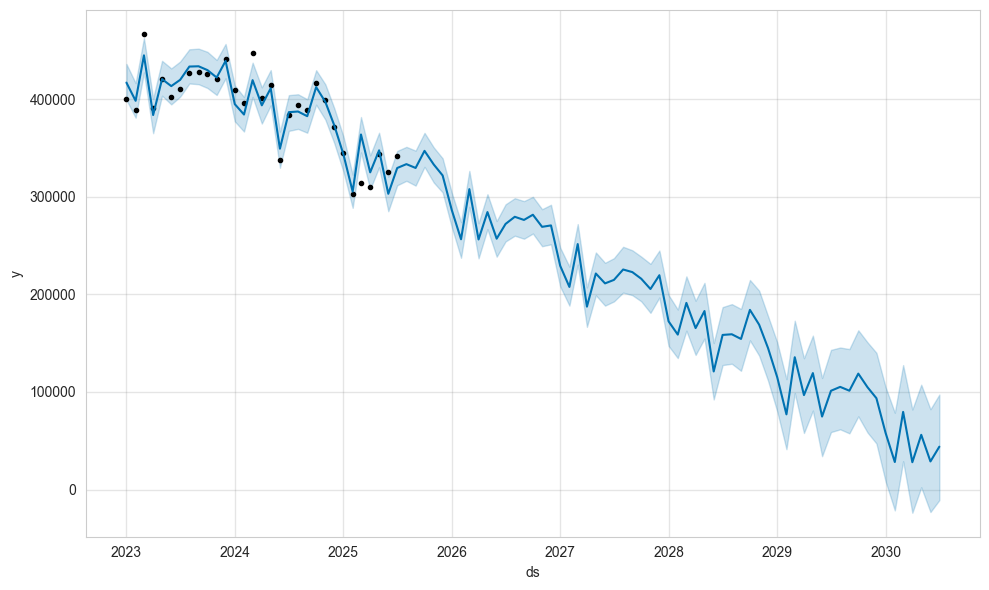

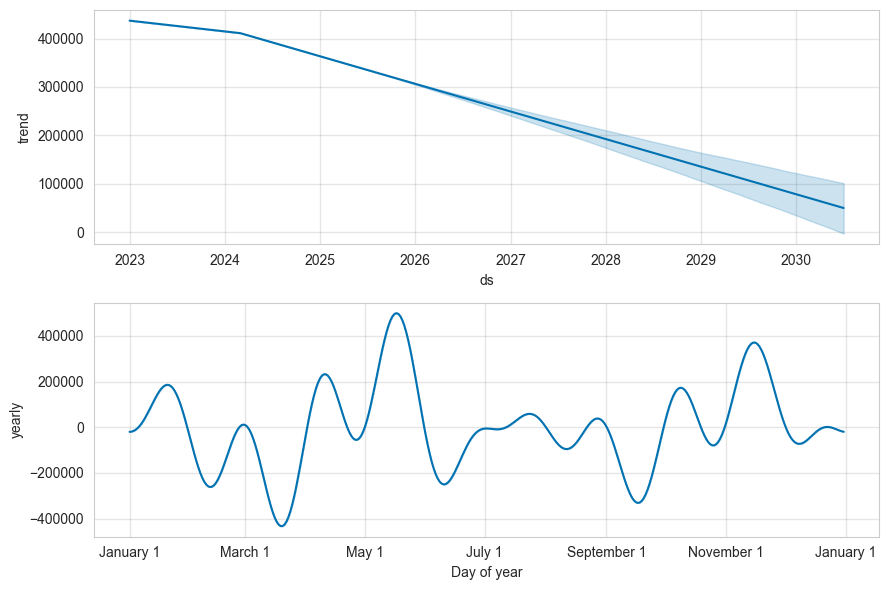

In [26]:
from prophet import Prophet
#Projeção de Vendas
df_produto1 = df_case[df_case['Produto'] == 'PRODUTO 1'].copy()

df_produto1['ds'] = pd.to_datetime(df_produto1['Data'])
df_produto1['y'] = df_produto1['Venda_Unidades']

df_prophet = df_produto1[['ds', 'y']]

m = Prophet()
m.fit(df_prophet)

future = m.make_future_dataframe(periods=60, freq='MS')

forecast = m.predict(future)

print("Projeção de Vendas do PRODUTO 1 para os Próximos 5 Anos:")

forecast_future = forecast[forecast['ds'].dt.year >= 2026].copy()

forecast_future['Ano'] = forecast_future['ds'].dt.year
forecast_future['Projecao_Vendas'] = forecast_future['yhat'].round(0).astype(int)

projected_sales = forecast_future.groupby('Ano')['Projecao_Vendas'].sum().reset_index()
projected_sales.rename(columns={'Projecao_Vendas': 'Vendas Projetadas (Unidades)'}, inplace=True)

print(projected_sales)

fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)

O modelo de séries temporais (Prophet) corrigiu a projeção inicial, que era fixa, e revelou uma tendência de queda nas vendas para os próximos cinco anos. Essa projeção realista mostra que, apesar do preço ideal, o volume de vendas do Produto 1 pode diminuir significativamente.

# Conclusão

A Nova Química enfrenta um mercado altamente competitivo e uma queda nas vendas, e busca reverter essa situação através de uma análise de dados. O produto da empresa é o PRODUTO 1, e todos os outros produtos (PRODUTO 2 a PRODUTO 6) são da concorrência.
A principal concorrência é o (PRODUTO 2), com uma alta correlação de preços de 0.73. As flutuações de preço são as mais relevantes para realizar uma estratégia.
A análise utilizou um modelo para determinar o preço ideal de 12.50 para o PRODUTO 1. Esse valor foi encontrado ao projetar a receita e o lucro para uma série de preços, incluindo preços que podem não ter sido observados nos dados históricos.
A extrapolação foi necessária para identificar o ponto de preço que maximizaria a receita ou o lucro.
O preço de R$ 12,50 é uma boa estratégia para o curto prazo, focada em rentabilidade, contudo, a projeção de queda nas vendas a longo prazo exige uma análise mais estruturada.

# Respondendo as Perguntas

**1.** Produto 2.

**2.** A elasticidade é cruzada com o Produto 3.

**3.** Preço ideal - R$12.50 para o Produto 1.

**4.** Utilizando um modelo preditivo de séries temporais (Prophet), indica uma tendência de queda gradual no volume de vendas. No entanto, a projeção de vendas mostra um declínio acentuado no longo prazo, o que indica a necessidade de uma estratégia mais estruturada. A empresa deve considerar investir em marketing, inovação ou diversificação do portfólio para reverter essa tendência e garantir a sustentabilidade do negócio.

**5.** Programação Python, utilizando as bibliotecas pandas para manipulação de dados, numpy para cálculos numéricos e scikit-learn para a criação do modelo preditivo.

# **Nathália Sorg**